In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv(r'D:\vs code projects\rental_analysis\data\interim\Gurugram\flat_house_data_outlier_updated.csv')

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,supertech araville,sector 79,0.71,5521.0,1286.0,Built Up area: 1295 (120.31 sq.m.),2,2,0,9.0,NaN,Under Construction,NaN,1295.0,NaN,0,0,0,0,0,0,0,643.0
1,flat,supertech araville,sector 79,0.95,6209.0,1530.0,Super Built up area 1530(142.14 sq.m.),2,2,3,7.0,North-East,New Property,1530.0,NaN,NaN,1,0,0,0,0,0,49,765.0
2,flat,ireo skyon,sector 60,2.65,13125.0,2019.0,Super Built up area 2045(189.99 sq.m.)Built Up...,3,4,3+,7.0,North-East,Moderately Old,2045.0,2037.0,2019.0,0,1,0,0,0,1,152,673.0
3,flat,bhemerlei,sohna road,0.69,5100.0,1353.0,Built Up area: 1350 (125.42 sq.m.),2,2,2,3.0,NaN,Under Construction,NaN,1350.0,NaN,0,0,0,0,0,0,0,676.5
4,flat,tata gurgaon gateway,sector 113,2.45,10788.0,2271.0,Super Built up area 2225(206.71 sq.m.),3,3,3,8.0,North,Relatively New,2225.0,NaN,NaN,0,0,0,0,0,0,110,757.0


In [5]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1064
agePossession             0
super_built_up_area    1741
built_up_area          2052
carpet_area            1747
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

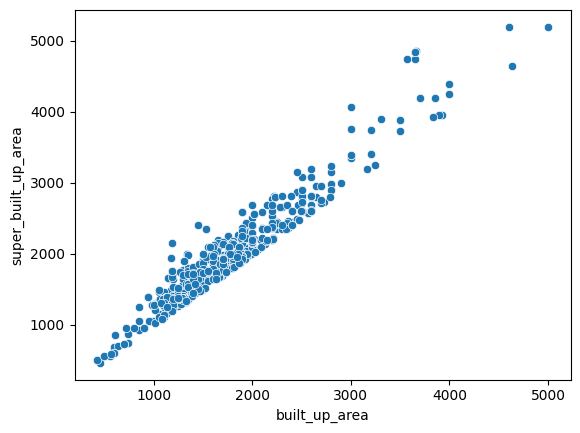

In [7]:
sns.scatterplot(x=df['built_up_area'],y=df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

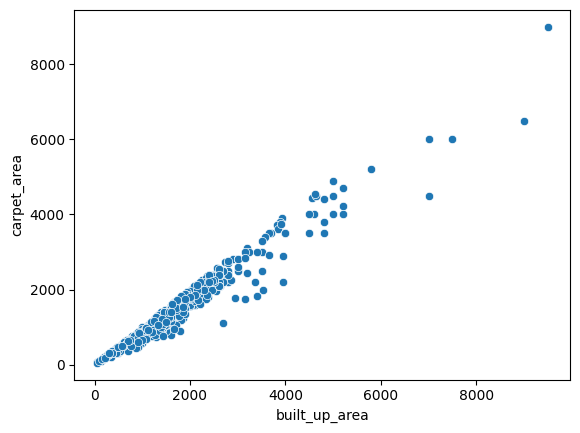

In [9]:
sns.scatterplot(x=df['built_up_area'],y=df['carpet_area'])

In [10]:
df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio


In [11]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [12]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [13]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [14]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.1048701298701298 0.900140056022409


In [15]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [19]:
sbc_df['built_up_area']=sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

C:\Users\msi 1\AppData\Local\Temp\ipykernel_4420\3173561431.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  sbc_df['built_up_area']=sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)


In [20]:
df.update(sbc_df)

In [21]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1064
agePossession             0
super_built_up_area    1741
built_up_area          1624
carpet_area            1747
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [22]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [24]:
sb_df['built_up_area']=sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

C:\Users\msi 1\AppData\Local\Temp\ipykernel_4420\506460479.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  sb_df['built_up_area']=sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)


In [25]:
df.update(sb_df)

In [26]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1064
agePossession             0
super_built_up_area    1741
built_up_area           721
carpet_area            1747
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [27]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [28]:
c_df['built_up_area']=c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

C:\Users\msi 1\AppData\Local\Temp\ipykernel_4420\1497293999.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c_df['built_up_area']=c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)


In [29]:
df.update(c_df)

In [30]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1064
agePossession             0
super_built_up_area    1741
built_up_area             0
carpet_area            1747
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

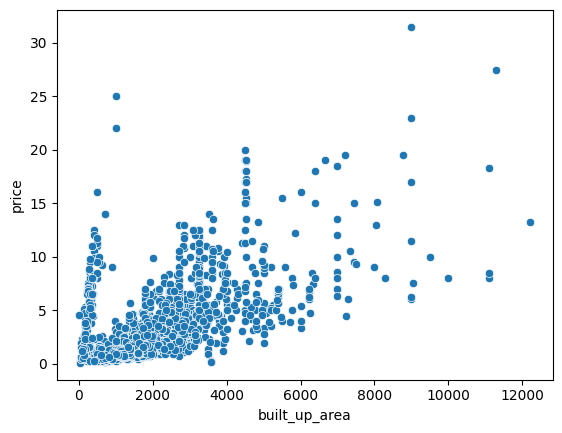

In [32]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [33]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]
anamoly_df

,price,area,built_up_area
6,2.68,1557.0,1557.0
18,4.25,1620.0,200.0
44,2.65,1433.0,1297.0
138,4.50,1350.0,1350.0
143,2.80,2047.0,1971.0
...,...,...,...
3604,6.50,3240.0,360.0
3629,2.55,2273.0,1773.0
3630,2.58,2200.0,1991.0
3637,2.70,1650.0,1833.0


In [34]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [35]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

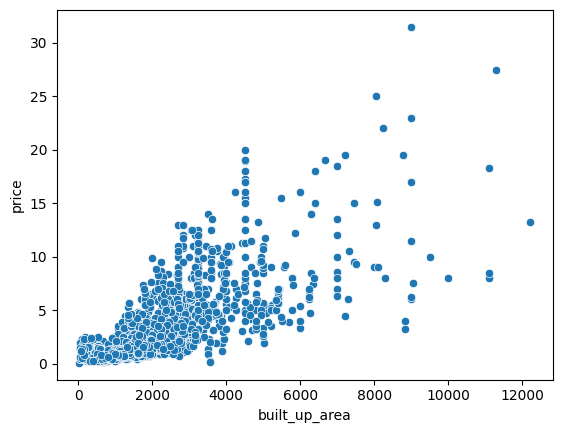

In [36]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [37]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)

In [38]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,supertech araville,sector 79,0.71,5521.0,2,2,0,9.0,NaN,Under Construction,1295.0,0,0,0,0,0,0,0
1,flat,supertech araville,sector 79,0.95,6209.0,2,2,3,7.0,North-East,New Property,1385.0,1,0,0,0,0,0,49
2,flat,ireo skyon,sector 60,2.65,13125.0,3,4,3+,7.0,North-East,Moderately Old,2037.0,0,1,0,0,0,1,152
3,flat,bhemerlei,sohna road,0.69,5100.0,2,2,2,3.0,NaN,Under Construction,1350.0,0,0,0,0,0,0,0
4,flat,tata gurgaon gateway,sector 113,2.45,10788.0,3,3,3,8.0,North,Relatively New,2014.0,0,0,0,0,0,0,110


In [39]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
202,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,1,NaN,NaN,Relatively New,3240.0,0,0,0,0,0,0,21
339,house,ansal sushant lok,sector 43,10.50,27911.0,4,4,2,NaN,North-East,Old Property,3762.0,0,1,0,0,0,0,59
418,house,dlf new town heights,sector 86,2.47,7719.0,4,4,3+,NaN,West,Moderately Old,2800.0,0,1,0,1,0,1,130
541,house,independent,sector 2,5.60,17284.0,8,6,3+,NaN,South-West,Moderately Old,3240.0,1,1,1,1,0,0,0
980,house,emaar mgf marbella,sector 66,9.00,21251.0,4,4,3+,NaN,South-West,Relatively New,5200.0,0,1,1,1,0,1,114
1197,flat,NaN,sector 78,0.60,3692.0,2,2,0,NaN,NaN,Under Construction,1625.0,0,0,0,0,0,0,0
1368,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,2,NaN,East,Moderately Old,3240.0,0,1,1,1,0,0,88
1515,house,independent,sector 4,4.12,8889.0,2,1,3+,NaN,NaN,Moderately Old,4635.0,0,0,0,0,0,0,0
2094,house,independent,sector 4,0.65,11111.0,4,2,2,NaN,NaN,Moderately Old,585.0,0,0,0,0,0,0,0
2135,house,independent,sector 24,1.45,2984.0,3,3,1,NaN,NaN,Old Property,540.0,0,0,0,0,0,0,9


In [41]:
df[df['property_type'] == 'house']['floorNum'].median()

np.float64(2.0)

In [43]:
df['floorNum']=df['floorNum'].fillna(2.0,inplace=True)

C:\Users\msi 1\AppData\Local\Temp\ipykernel_4420\3117717830.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['floorNum']=df['floorNum'].fillna(2.0,inplace=True)


In [44]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1064
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

<Axes: >

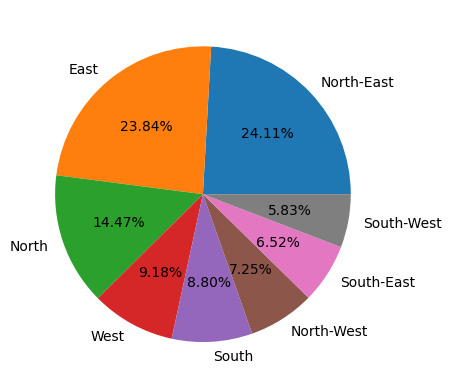

In [45]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [46]:
df.drop(columns=['facing'],inplace=True)

In [47]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [49]:
df=df[~df['society'].isnull()]

In [50]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [51]:
df['agePossession'].value_counts()

agePossession
Relatively New        1628
New Property           588
Moderately Old         543
Undefined              319
Old Property           297
Under Construction     280
Name: count, dtype: int64

In [52]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
27,house,surendra homes dayaindependentd colony,sector 6,0.75,15625.0,4,4,2,1.0,Undefined,480.0,0,0,0,0,0,0,0
89,house,ninex city,sector 76,1.75,6250.0,4,4,0,14.0,Undefined,3111.0,0,0,0,0,0,0,0
100,house,dlf city plot phase 4,sector 28,13.00,17931.0,10,10,3+,1.0,Undefined,8056.0,0,0,0,0,0,0,0
128,flat,eldeco accolade,sector 33,1.20,8043.0,2,2,2,0.0,Undefined,1492.0,0,0,0,0,0,0,56
135,flat,eldeco accolade,sector 33,1.20,8043.0,2,2,2,0.0,Undefined,1492.0,0,0,0,0,0,0,56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3611,flat,trisara our homes 3,sohna road,0.40,4479.0,2,2,2,1.0,Undefined,900.0,0,0,0,0,0,0,0
3632,house,independent,sector 3 phase 3 extension,0.85,8500.0,1,1,0,1.0,Undefined,1000.0,0,0,0,0,0,0,0
3642,house,independent,sector 50,13.20,27155.0,6,6,0,2.0,Undefined,4861.0,0,0,0,0,0,0,0
3643,flat,signature global infinity mall,sector 36,0.41,6269.0,2,2,3,3.0,Undefined,654.0,0,0,0,0,0,0,0


In [53]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [54]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [55]:
df['agePossession'].value_counts()

agePossession
Relatively New        1755
New Property           629
Moderately Old         580
Old Property           335
Under Construction     297
Undefined               59
Name: count, dtype: int64

In [56]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [ ]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [58]:
df['agePossession'].value_counts()

agePossession
Relatively New        1767
New Property           630
Moderately Old         583
Old Property           341
Under Construction     297
Undefined               37
Name: count, dtype: int64

In [59]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [60]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [61]:
df['agePossession'].value_counts()

agePossession
Relatively New        1769
New Property           630
Moderately Old         618
Old Property           341
Under Construction     297
Name: count, dtype: int64

In [62]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [63]:
df.to_csv(r'D:\vs code projects\rental_analysis\data\interim\Gurugram\flat_house_data_missing_value_imputation.csv',index=False)